In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the Excel file
file_path = 'dv0_witstraw.xlsx'  # Use the correct path for your environment
data = pd.read_excel(file_path)
# print("Columns in the dataset:")
# print(data.columns.tolist())
# Display the first few rows of the dataset to understand its structure
# print("Original Data Sample:")

df = data[data['Label'] == 1]
df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})

df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
df["Label"] = df["Label"].map({"Drinking": 1, "Not_Drinking": 0})
df['temp'] = df ['temp'].map({'h':2, 'c':0, 'n': 1})
# print(data.head())
# Group by Participant_ID and sip_id to count time steps and extract dV and Label
grouped_data = df.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # Taking the first dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first') ,
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Assuming the label is consistent, take the first
).reset_index()

# Display the grouped data before creating X and y
print("\nGrouped Data Sample:")
print(grouped_data.head())

# Prepare features (X) and target (y)
X = grouped_data[['time_steps','Gender', 'Container_Weight','temp', 'sip_id']]  # Features
y = grouped_data['dV']             # Target variable

# Display X and y before proceeding
print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))

# Split the data into training and testing sets (optional)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can proceed with training your model using X and y as needed


Grouped Data Sample:
   Participant_ID  sip_id  time_steps         dV  Gender  temp  \
0               9       1          17   8.666667       0     0   
1               9       2          18  11.809524       0     0   
2               9       3          20  10.857143       0     0   
3               9       4          21  13.333333       0     0   
4               9       5          14  13.238095       0     0   

   Container_Weight  Label  
0                 3    NaN  
1                 3    NaN  
2                 3    NaN  
3                 3    NaN  
4                 3    NaN  

Features (X):
    time_steps  Gender  Container_Weight  temp  sip_id
0           17       0                 3     0       1
1           18       0                 3     0       2
2           20       0                 3     0       3
3           21       0                 3     0       4
4           14       0                 3     0       5
5           15       0                 3     0       6
6      

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18472/569078237.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18472/569078237.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18472/569078237.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [3]:
# Check for time_steps equal to zero
zero_time_steps_mask = grouped_data['dV'] == 0  # Creates a boolean mask
zero_time_steps_indices = grouped_data.index[zero_time_steps_mask].tolist()  # Get indices of rows where time_steps is zero
zero_time_steps_count = zero_time_steps_mask.sum()  # Count how many are True in the mask

# Display results
print(f"\nIndices where time_steps are 0: {zero_time_steps_indices}")
print(f"Total number of time_steps that are 0: {zero_time_steps_count}")


Indices where time_steps are 0: [138]
Total number of time_steps that are 0: 1


In [4]:
# Retrieve the records from grouped_data using the identified indices
zero_time_steps_records = grouped_data.loc[zero_time_steps_indices]

# Get the Participant_ID and sip_id
participant_ids_and_sip_ids = zero_time_steps_records[['Participant_ID', 'sip_id']]

# Display the result
print("\nRecords with zero time_steps:")
print(participant_ids_and_sip_ids)


Records with zero time_steps:
     Participant_ID  sip_id
138              58       1


In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]


In [4]:

# Create a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)




In [5]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [6]:
model = SVR(kernel='poly')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [7]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [13]:
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [9]:
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

NameError: name 'XGBRegressor' is not defined

Mean Squared Error (MSE): 436.5684
Root Mean Squared Error (RMSE): 20.8942
R-squared (R²): -3.8485
Root Mean Squared Percentage Error (RMSPE): inf%
     Actual  Predicted
121    23.0  21.131587
122    34.2  24.772683
123    21.3  21.168035
124    29.6  28.903433
125    17.1  23.435497
126    25.5  19.637462
127    31.3  18.594642
128    33.0  33.002883
129    17.4  35.870734
130    23.5  40.096280
131    18.7  34.694538
132    22.3  29.206879
133    16.3  32.398573
134    21.2  47.318566
135    17.3  29.625943
136    21.4  30.991475
137    19.5  27.793478
138     0.0  32.242205
139    11.0  41.210264
140    11.6  47.521258
141     9.5  45.222602
142    13.6  52.188841
143     7.0  39.516676
144    13.6  50.026693
145    10.7  49.353941
146    11.8  33.487240
147    24.8  36.461515
148    45.0  54.060080
149    25.0  22.787349
150     0.8  21.940332
151    22.5  24.570533


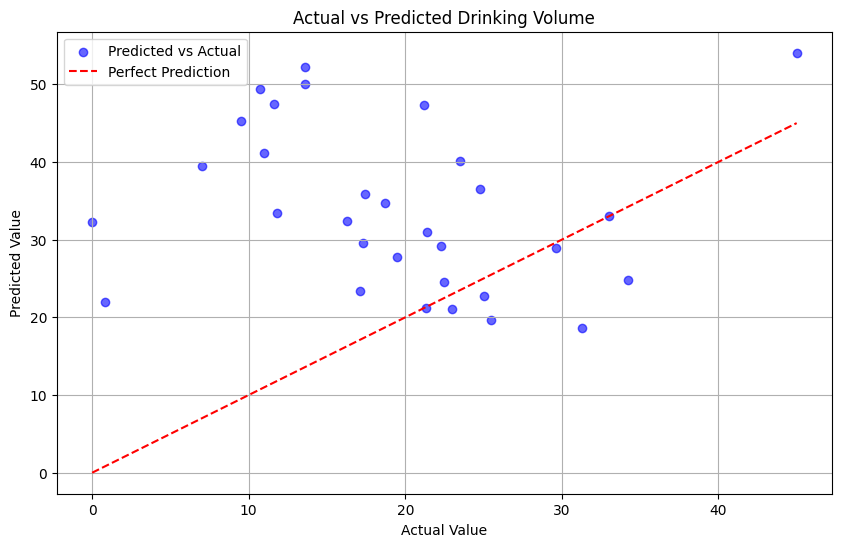

In [14]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(50))
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted Drinking Volume')
plt.legend()
plt.grid()
plt.show()

In [12]:
# plt.figure(figsize=(10, 6))
# plt.scatter(X, y, color='blue', label='Predicted vs Actual', alpha=0.6)
# # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
# plt.xlabel('timestamp')
# plt.ylabel('Volume')
# plt.title('All data plot')
# plt.legend()
# plt.grid()
# plt.show()


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 225.2446
Root Mean Squared Error (RMSE): 15.0082
R-squared (R²): -1.5016
Root Mean Squared Percentage Error (RMSPE): inf%
     Actual  Predicted
121    23.0  29.057021
122    34.2  28.426087
123    21.3  26.313630
124    29.6  27.460525
125    17.1  24.459154


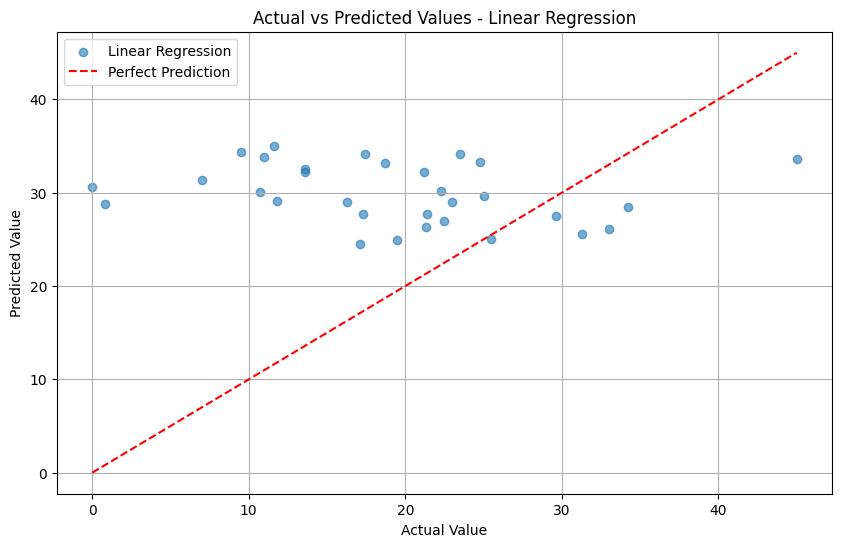


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 103.4907
Root Mean Squared Error (RMSE): 10.1730
R-squared (R²): -0.1494
Root Mean Squared Percentage Error (RMSPE): inf%
     Actual  Predicted
121    23.0  21.134163
122    34.2  21.289356
123    21.3  19.716020
124    29.6  22.082566
125    17.1  19.352689


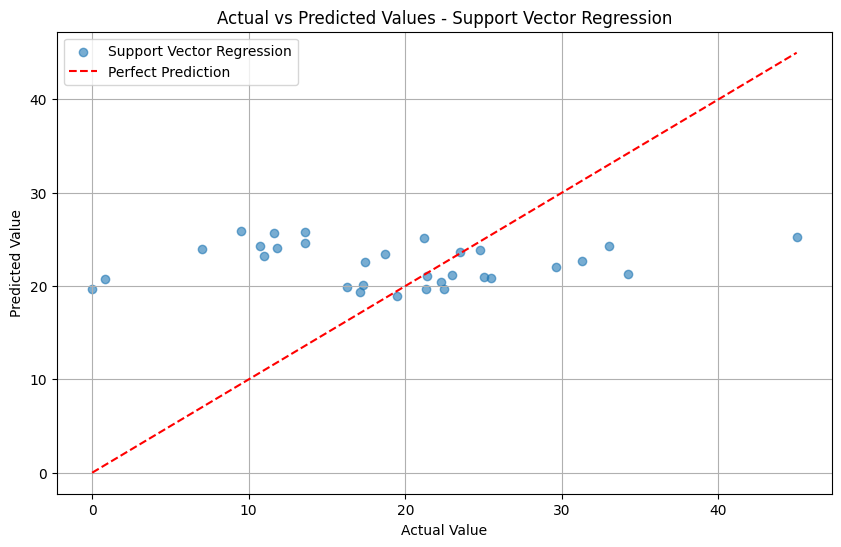


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 593.1690
Root Mean Squared Error (RMSE): 24.3551
R-squared (R²): -5.5877
Root Mean Squared Percentage Error (RMSPE): inf%
     Actual  Predicted
121    23.0       28.1
122    34.2       34.0
123    21.3       15.1
124    29.6       24.0
125    17.1       19.5


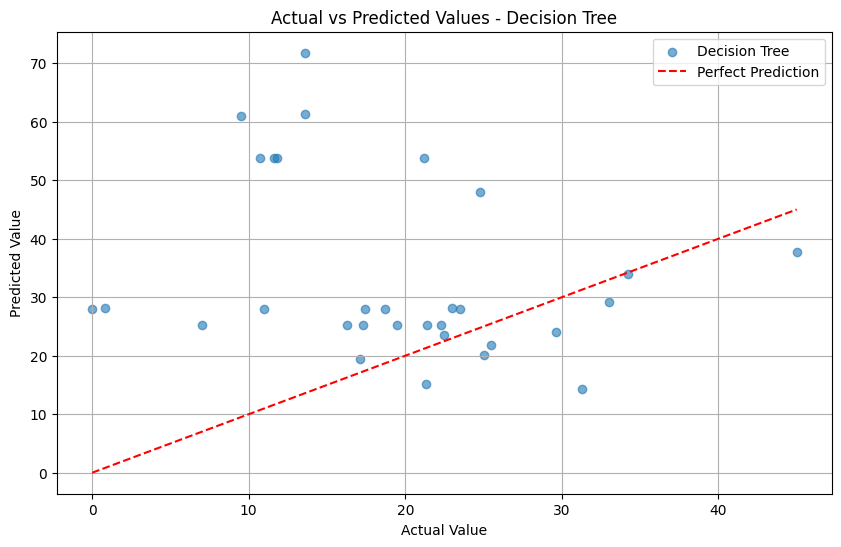


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 429.2628
Root Mean Squared Error (RMSE): 20.7187
R-squared (R²): -3.7674
Root Mean Squared Percentage Error (RMSPE): inf%
     Actual  Predicted
121    23.0  25.004565
122    34.2  27.688976
123    21.3  18.304000
124    29.6  25.077736
125    17.1  19.563000


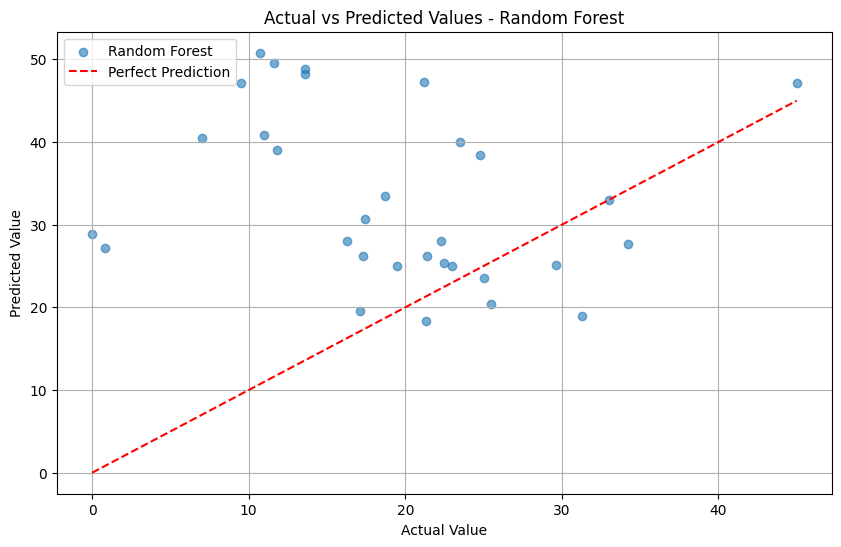


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 436.5684
Root Mean Squared Error (RMSE): 20.8942
R-squared (R²): -3.8485
Root Mean Squared Percentage Error (RMSPE): inf%
     Actual  Predicted
121    23.0  21.131587
122    34.2  24.772683
123    21.3  21.168035
124    29.6  28.903433
125    17.1  23.435497


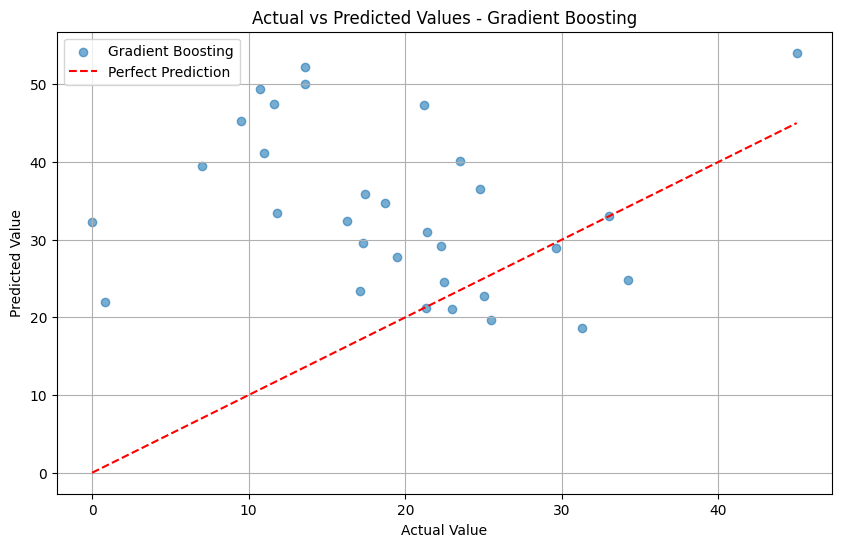


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 195.0525
Root Mean Squared Error (RMSE): 13.9661
R-squared (R²): -1.1662
Root Mean Squared Percentage Error (RMSPE): inf%
     Actual  Predicted
121    23.0  22.287619
122    34.2  20.147619
123    21.3  21.143810
124    29.6  24.869630
125    17.1  17.922857


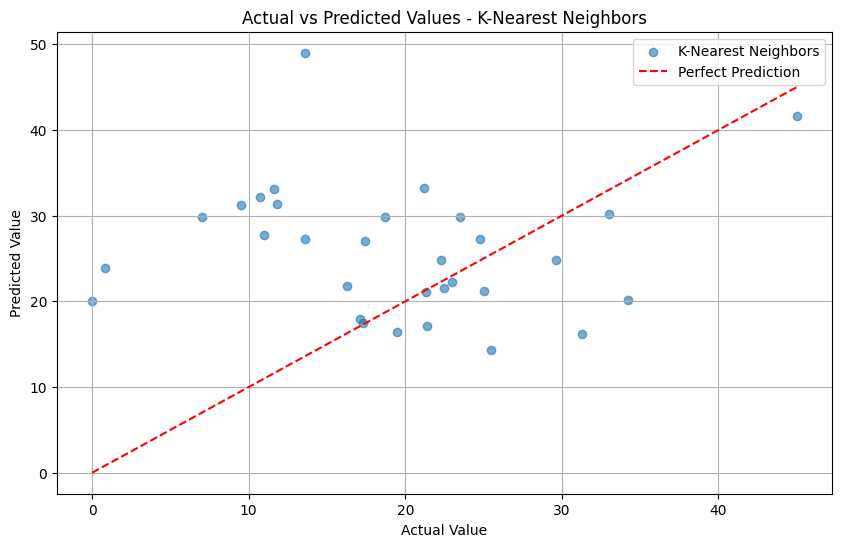

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    # "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()